# Graphulator Tutorial

This tutorial demonstrates how to use the `graph_primitives` module from Graphulator to create custom graphs programmatically.

Graphulator provides a powerful graph drawing library for creating coupled mode theory diagrams and quantum circuit visualizations.

## Setup

First, import the necessary modules:

In [1]:
import matplotlib.pyplot as plt
import graphulator.graph_primitives as gp
import graphulator.graphulator_config as config
from ipywidgets import interact

# Example 0: 1 node
A 1 $\times$ 1 matrix,
$$
\mathbf{M} = \left[\Delta_A\right]
$$
represented as a graph.

You *must* supply a `label` and a location tuple `xy`. Everything else is automated, but you'll need to override the default behaviors in more complex graphs to make anything look nice.

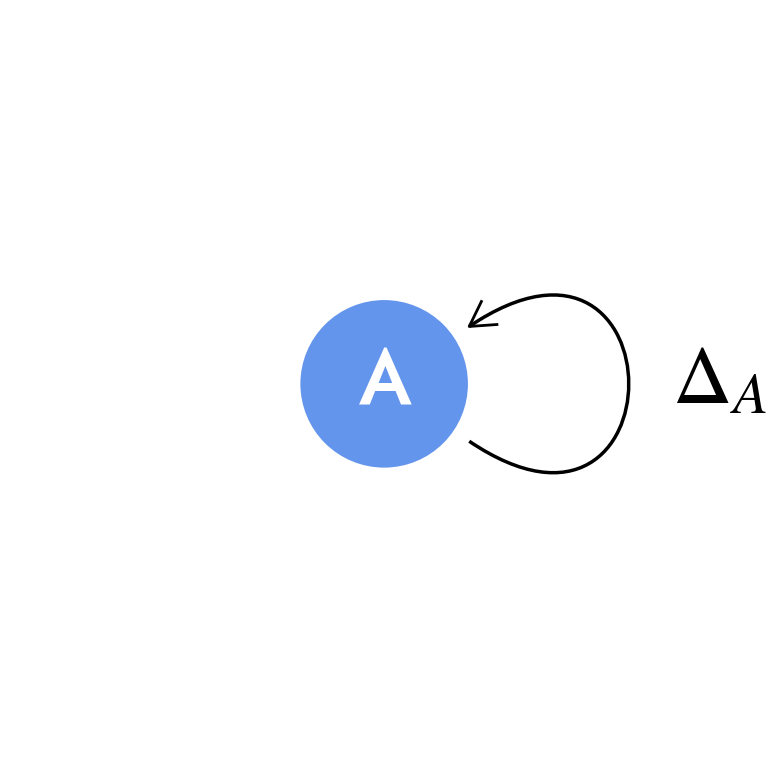

In [2]:
graph = gp.GraphCircuit()
graph.addnode(label='A',xy=(0,0))
graph.draw()

# plt.axis('on')
# plt.grid(True)

## Example 1: Simple Three-Node Graph

Let's create a simple graph with three nodes (A, B, C) arranged in a triangle with connecting edges.

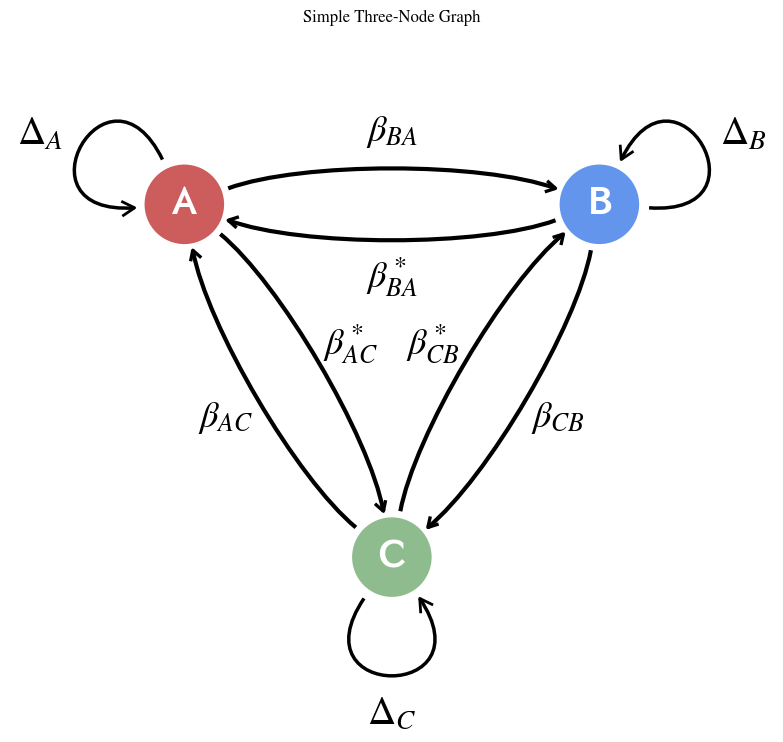

In [3]:
# Create a graph circuit
graph = gp.GraphCircuit()

# Add nodes with positions
graph.addnode(label='A', xy=(-10, 0), nodecolor=config.MYCOLORS['RED'], selfloopangle=150)
graph.addnode(label='B', xy=(10, 0), nodecolor=config.MYCOLORS['BLUE'], selfloopangle=30)
graph.addnode(label='C', xy=(0, -17), nodecolor=config.MYCOLORS['GREEN'], selfloopangle=270)

# Add edges between nodes
graph.addedge(fromnode='A', tonode='B', 
              theta=20,
              label=[r'$\beta_{BA}$', r'$\beta_{BA}^*$'],
              labeloffset=3.5,
              labelfontsize=36,
              style='loopy')

graph.addedge(fromnode='B', tonode='C',
              theta=20,
              label=[r'$\beta_{CB}$', r'$\beta_{CB}^*$'],
              labeloffset=3.5,
              labelfontsize=36,
              style='loopy')

graph.addedge(fromnode='C', tonode='A',
              theta=20,
              label=[r'$\beta_{AC}$', r'$\beta_{AC}^*$'],
              labeloffset=3.5,
              labelfontsize=36,
              style='loopy')

# Draw the graph
graph.draw(figsize=8, overfrac=0.2)
plt.axis('off')
plt.title('Simple Three-Node Graph')
plt.show()

## Example 2: Graph with Self-Loops

Nodes can have self-loops to represent self-coupling or detuning.

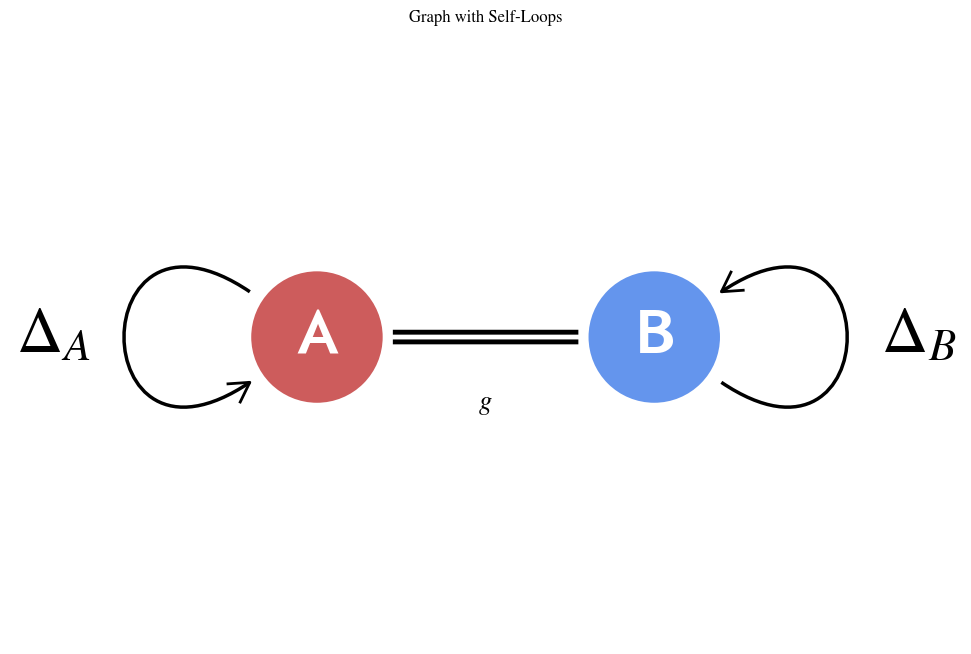

In [4]:
# Create a new graph
graph = gp.GraphCircuit()

# Add nodes with self-loops
graph.addnode(label='A', xy=(-5, 0), 
              nodecolor=config.MYCOLORS['RED'],
              drawselfloop=True,
              selflooplabel=r'$\Delta_A$',
              selfloopangle=180)  # Self-loop on the left

graph.addnode(label='B', xy=(5, 0), 
              nodecolor=config.MYCOLORS['BLUE'],
              drawselfloop=True,
              selflooplabel=r'$\Delta_B$',
              selfloopangle=0)  # Self-loop on the right

# Add edge between nodes
graph.addedge(fromnode='A', tonode='B',
              label=[None, r'$g$'],
              style='double',
              whichedges='backward',
             )

# Draw the graph
graph.draw(figsize=10, overfrac=0.3)
plt.axis('off')
plt.title('Graph with Self-Loops')
plt.show()

## Example 3: Different Edge Styles

Graphulator supports three edge styles:
- `'loopy'`: Curved edges (default)
- `'single'`: Single straight arrow
- `'double'`: Double straight arrows

Self-loop labels are autogenerated with some default styling

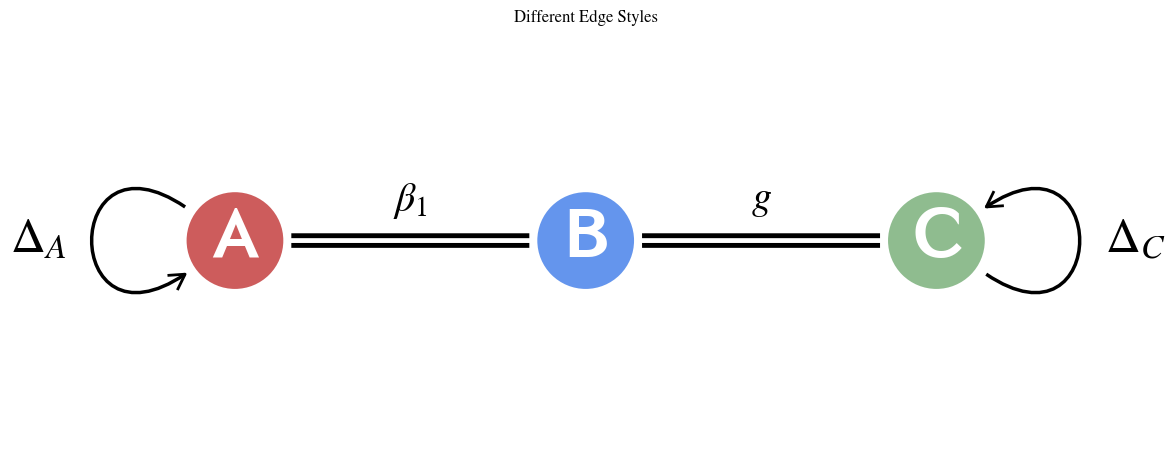

In [29]:
# Create graph
graph = gp.GraphCircuit()

# Add nodes in a line
graph.addnode(label='A', xy=(-14, 0), fontscale=1.5, nodecolor=config.MYCOLORS['RED'], selfloopangle=180)
graph.addnode(label='B', xy=(0, 0), fontscale=1.5, nodecolor=config.MYCOLORS['BLUE'], drawselfloop=False)
graph.addnode(label='C', xy=(14, 0), fontscale=1.5, nodecolor=config.MYCOLORS['GREEN'])

# Loopy style
graph.addedge(fromnode='A', tonode='B', 
              label=[r'$\beta_1$', None], labeloffset=1.6,labelfontsize=32,
              style='double')

# Double style
graph.addedge(fromnode='B', tonode='C',
              label=[r'$g$', None], labeloffset=1.6, labelfontsize=32,
              style='double',
              whichedges='forward')

# Draw the graph
graph.draw(figsize=12, overfrac=0.2)
plt.axis('off')
plt.title('Different Edge Styles')
plt.show()

## Example 4: Customizing Node and Edge Properties

You can customize node size, label size, and other properties. The following widget shows some of the properties you can customize

In [65]:
@interact(selfloop_A_angle=(0, 360, 10), selfloop_B_angle=(0, 360, 10), selfloopsscaleA = (0.5,3.0,0.1), selfloopsscaleB = (0.5,3.0,0.1), nodeAsize = (0.5,3.0,0.1), nodeBsize = (0.5,3.0,0.1), edgestyle = ['loopy', 'single', 'double'],whichedges = ['forward', 'backward', 'both'], edgelw = (0.5,15,0.5), edgelabel_offset = (0.5,6.0,0.1), edgelabel_fontsize = (12,72,2), conjugateB = [False, True], showaxisgrid = [False, True])

def graph_interactive(selfloop_A_angle=180, selfloop_B_angle=0, selfloopsscaleA=1.0, selfloopsscaleB=1.0, nodeAsize=1.5, nodeBsize=1.5, conjugateB=False, edgestyle='double', whichedges='both', edgelw=9.0, 
                      edgelabel_offset=3.5, edgelabel_fontsize=36, showaxisgrid=False):
    # Create a new graph
    graph = gp.GraphCircuit()

    # Add nodes with self-loops

    if conjugateB:
        nodelabelB = r'-$\Delta_B^*$'
    else:
        nodelabelB = r'$\Delta_B$'
        
    graph.addnode(label='A', xy=(0, 0), 
                nodecolor=config.MYCOLORS['RED'],
                R = nodeAsize,
                drawselfloop=True,
                selflooplabel=r'$\Delta_A$',
                selfloopangle=selfloop_A_angle,
                selfloopscale=selfloopsscaleA)  # Self-loop on the left

    graph.addnode(label='B', xy=(10, 0), 
                nodecolor=config.MYCOLORS['BLUE'],
                R = nodeBsize,
                drawselfloop=True,
                selflooplabel=nodelabelB,
                selfloopangle=selfloop_B_angle,
                selfloopscale=selfloopsscaleB,
                conj=conjugateB
                )  # Self-loop on the right

    # Add edge between nodes
    graph.addedge(fromnode='A', tonode='B',
                label=[None, r'$g$'],
                style=edgestyle,
                loopkwargs = {'lw':edgelw},
                labeloffset=edgelabel_offset,
                labelfontsize=edgelabel_fontsize,
                whichedges=whichedges)

    # Draw the graph
    graph.draw(figsize=10, overfrac=0.3)
    if showaxisgrid:
        plt.axis('on')
        plt.grid(True)
    plt.show()

interactive(children=(IntSlider(value=180, description='selfloop_A_angle', max=360, step=10), IntSlider(value=…

## Example 5: Complex Network

Create a more complex network with multiple nodes and connections.

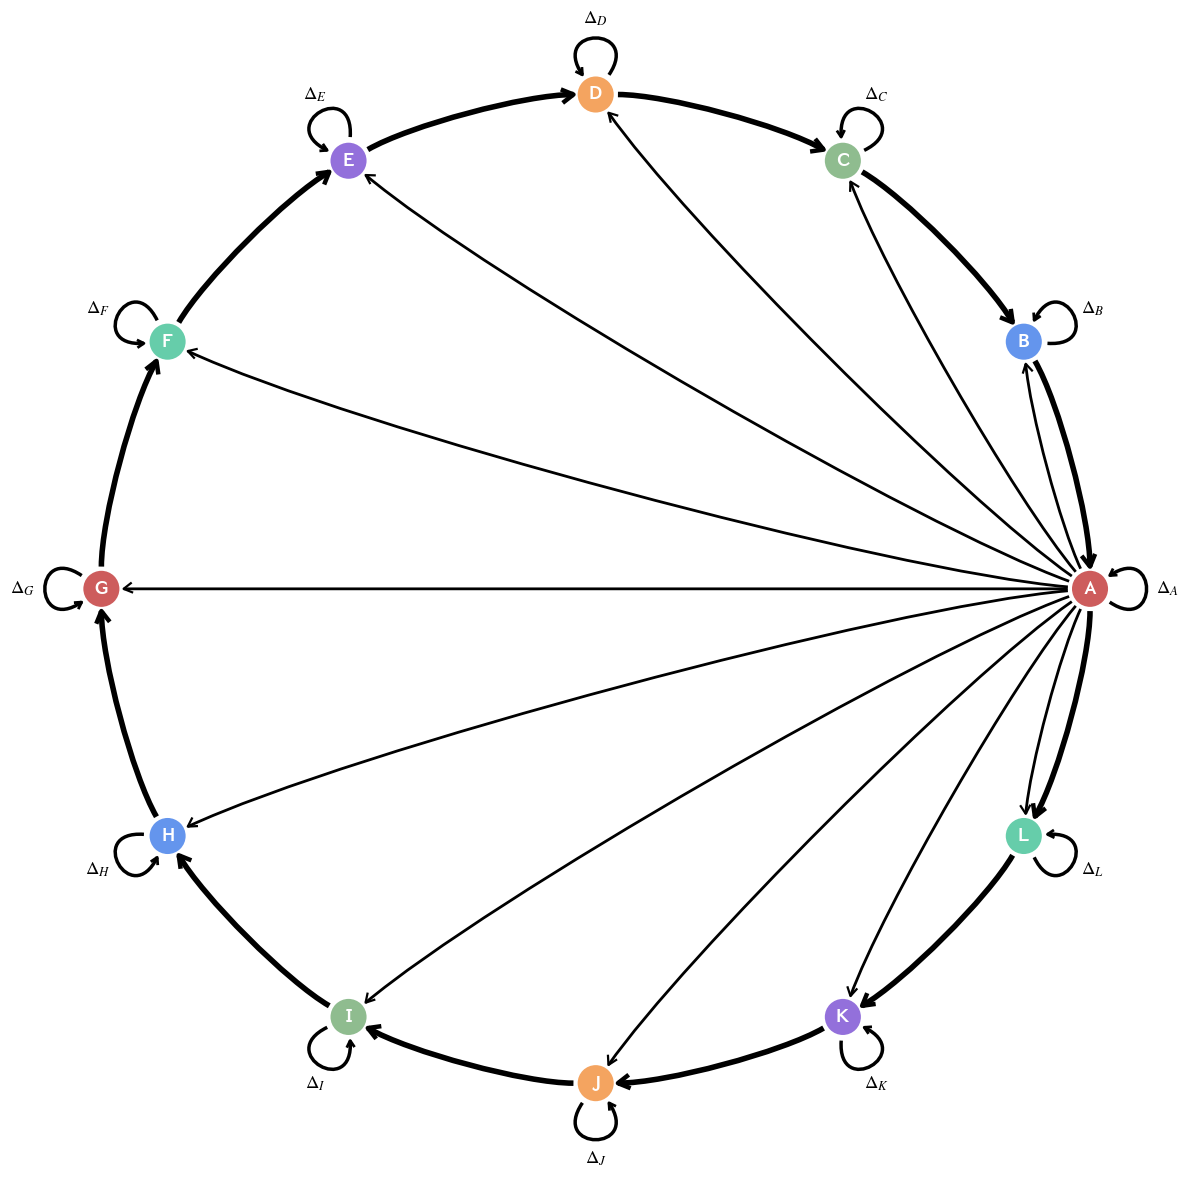

In [90]:
import numpy as np

# Create graph
graph = gp.GraphCircuit()

# Create nodes in a circular pattern
n_nodes = 12
radius = 50
colors = ['RED', 'BLUE', 'GREEN', 'ORANGE', 'PURPLE', 'TEAL']

for i in range(n_nodes):
    angle = 2 * np.pi * i / n_nodes
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    label = chr(65 + i)  # A, B, C, D, E, F
    
    graph.addnode(label=label, xy=(x, y), 
                  nodecolor=config.MYCOLORS[colors[i % len(colors)]],
                  selfloopangle=i * 360 / n_nodes)

# Connect each node to its neighbors
for i in range(n_nodes):
    label1 = chr(65 + i)
    label2 = chr(65 + (i + 1) % n_nodes)
    graph.addedge(fromnode=label1, tonode=label2, style='loopy',whichedges='forward',
                  theta=15,loopkwargs={'lw': 4, 'arrowlength': 1.},
                  reverse=True)

# Add some cross connections
# graph.addedge(fromnode='A', tonode='D', style='single', whichedges='backward')
# graph.addedge(fromnode='B', tonode='E', style='single', whichedges='forward')

# add connections from first node to all other nodes
for i in range(1, n_nodes):
    label1 = 'A'
    label2 = chr(65 + i)
    if i < n_nodes / 2:
        sign = 1
    elif i > n_nodes / 2:
        sign = -1
    else:
        sign = 0
    graph.addedge(fromnode=label1, tonode=label2, style='loopy', whichedges='forward',
                #   label=[None, f'Conn to {label2}'],
                  labeloffset=2.5,
                  labelfontsize=20,
                  theta=sign*10,
                  loopkwargs={'lw': 2, 'arrowlength': 0.8})

# Draw the graph
graph.draw(figsize=12, overfrac=0.2)
plt.axis('off')
# plt.title('Complex Network')
plt.show()

## Rendering with LaTeX
By default, the `GraphCircuit` class renders graph labels using MathTeX. This is fast but also doesn't look as nice as LaTeX. If you have LaTeX installed, just set `use_latex=True` when you create the `GraphCircuit` object:

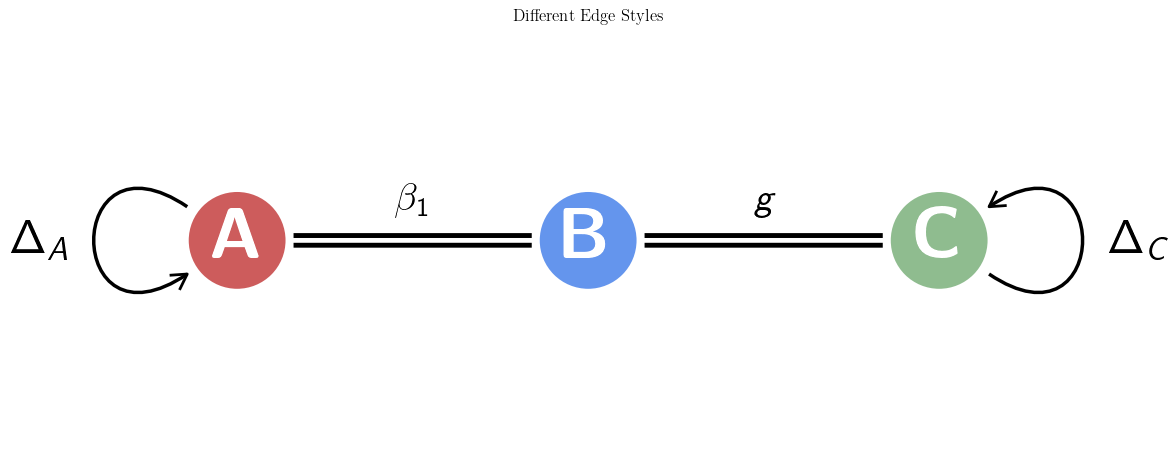

In [ ]:
# Create graph
graph = gp.GraphCircuit(use_latex=True) # <-- uses LaTeX for rendering labels (slower)

# Add nodes in a line
graph.addnode(label='A', xy=(-14, 0), fontscale=1.5, nodecolor=config.MYCOLORS['RED'], selfloopangle=180)
graph.addnode(label='B', xy=(0, 0), fontscale=1.5, nodecolor=config.MYCOLORS['BLUE'], drawselfloop=False)
graph.addnode(label='C', xy=(14, 0), fontscale=1.5, nodecolor=config.MYCOLORS['GREEN'])

# Loopy style
graph.addedge(fromnode='A', tonode='B', 
              label=[r'$\beta_1$', None], labeloffset=1.6,labelfontsize=32,
              style='double')

# Double style
graph.addedge(fromnode='B', tonode='C',
              label=[r'$g$', None], labeloffset=1.6, labelfontsize=32,
              style='double',
              whichedges='forward')

# Draw the graph
graph.draw(figsize=12, overfrac=0.2)
plt.axis('off')
plt.title('Different Edge Styles')
plt.show()

## Exporting Graphs

You can save graphs as PDF or SVG files:

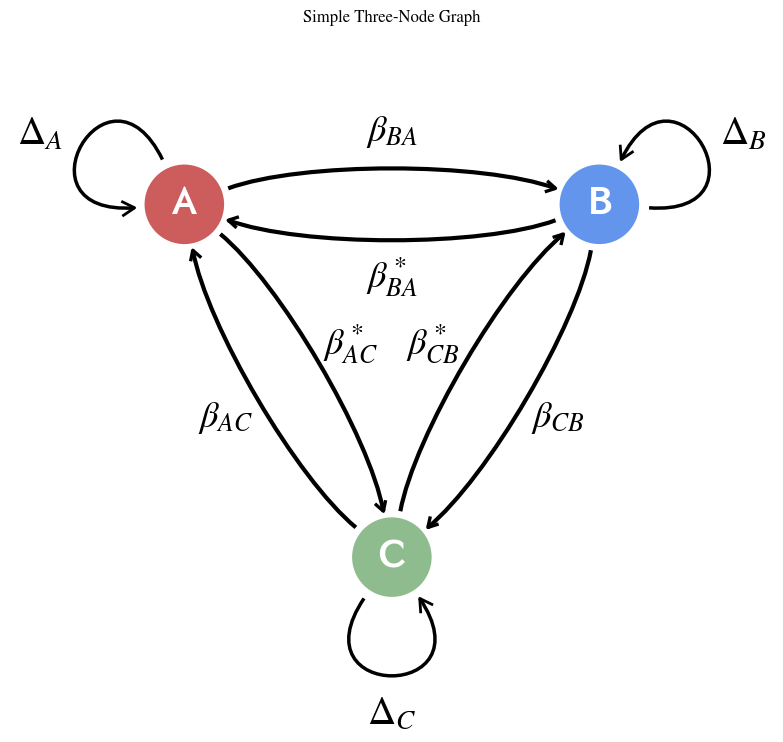

In [60]:
# Create a graph circuit
graph = gp.GraphCircuit()

# Add nodes with positions
graph.addnode(label='A', xy=(-10, 0), nodecolor=config.MYCOLORS['RED'], selfloopangle=150)
graph.addnode(label='B', xy=(10, 0), nodecolor=config.MYCOLORS['BLUE'], selfloopangle=30)
graph.addnode(label='C', xy=(0, -17), nodecolor=config.MYCOLORS['GREEN'], selfloopangle=270)

# Add edges between nodes
graph.addedge(fromnode='A', tonode='B', 
              theta=20,
              label=[r'$\beta_{BA}$', r'$\beta_{BA}^*$'],
              labeloffset=3.5,
              labelfontsize=36,
              style='loopy')

graph.addedge(fromnode='B', tonode='C',
              theta=20,
              label=[r'$\beta_{CB}$', r'$\beta_{CB}^*$'],
              labeloffset=3.5,
              labelfontsize=36,
              style='loopy')

graph.addedge(fromnode='C', tonode='A',
              theta=20,
              label=[r'$\beta_{AC}$', r'$\beta_{AC}^*$'],
              labeloffset=3.5,
              labelfontsize=36,
              style='loopy')

# Draw the graph
graph.draw(figsize=8, overfrac=0.2)
plt.axis('off')
plt.title('Simple Three-Node Graph')

# Save to file
plt.savefig('my_graph.pdf', bbox_inches='tight')
plt.savefig('my_graph.svg', bbox_inches='tight')

plt.show()

## Miscellaneous

It seems to be difficult to get any label (node, edge, self-loop) to automatically render such that text looks centered where you'd think it looks good. For this reason there are nudge and offset parameters that you're going to have to play with to place things in an aesthetically not-terrible way. Likewise, you will also want to play with label scaling. While it seems like you should really be able to automate most of these things to give something aesthetically pleasing, it's just not true, or at least very, very difficult to codify these pieces as automatic choices (which is part of why LaTeX typography choices are so complicated under the hood!).

In [ ]:
@interact(fontscaleA = (0.5,3.0,0.1), nodellabelAnudgex=(-3.0,3.0,0.1), nodelabelAnudgey=(-3.0,3.0,0.1),
          selflooplabelAnudgex=(-3.0,3.0,0.1), selflooplabelAnudgey=(-3.0,3.0,0.1),
          edgelabel_offset=(0.5,6.0,0.1), edgelabel_fontsize=(12,72,2))

def tmp(fontscaleA = 1.0, nodellabelAnudgex=0.0, nodelabelAnudgey=0.0,
        selflooplabelAnudgex=0.0, selflooplabelAnudgey=0.0,
        edgelabel_offset=3.5, edgelabel_fontsize=36):
    # Create a new graph
    graph = gp.GraphCircuit()

    # Add nodes with self-loops
    graph.addnode(label='A', xy=(-8, 0), 
                fontscale=fontscaleA,
                nodelabelnudge=(nodellabelAnudgex, nodelabelAnudgey),
                nodecolor='indianred',
                drawselfloop=True,
                selflooplabel=r'$\Delta_A$',
                selflooplabelnudge=(selflooplabelAnudgex, selflooplabelAnudgey),
                selfloopangle=180)  # Self-loop on the left

    graph.addnode(label='B', xy=(8, 0), 
                nodecolor='steelblue',
                drawselfloop=True,
                selflooplabel=r'$\Delta_B$',
                selfloopangle=0)  # Self-loop on the right

    # Add edge between nodes
    graph.addedge(fromnode='A', tonode='B',
                label=[r'$\beta$',r'$\beta^*$'], 
                labeloffset=edgelabel_offset, labelfontsize=edgelabel_fontsize,
                style='loopy',
                loopkwargs={'lw': 3.0})

    # Draw the graph
    graph.draw(figsize=10, overfrac=0.3)
    plt.axis('off')
    plt.title('Graph with Self-Loops')
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='fontscaleA', max=3.0, min=0.5), FloatSlider(value=0.…

## Next Steps

- Launch the GUI with `graphulator` command for interactive editing
- Explore the example graphs in the Examples menu
- Check the documentation for more advanced features



In [5]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I

# Define symbols
Delta_B, Delta_A, Delta_C, beta_AB, beta_CA, beta_CB = symbols('Delta_B Delta_A Delta_C beta_AB beta_CA beta_CB', complex=True)

# Build matrix M
M = Matrix([
    [Delta_B, beta_AB, beta_CB],
    [conjugate(beta_AB), Delta_A, beta_CA],
    [-conjugate(beta_CB), -conjugate(beta_CA), -conjugate(Delta_C)]
])

# Display matrix
print(M)

Matrix([[Delta_B, beta_AB, beta_CB], [conjugate(beta_AB), Delta_A, beta_CA], [-conjugate(beta_CB), -conjugate(beta_CA), -conjugate(Delta_C)]])


In [7]:
# conjugate(M[1,0])
M

Matrix([
[            Delta_B,             beta_AB,             beta_CB],
[ conjugate(beta_AB),             Delta_A,             beta_CA],
[-conjugate(beta_CB), -conjugate(beta_CA), -conjugate(Delta_C)]])

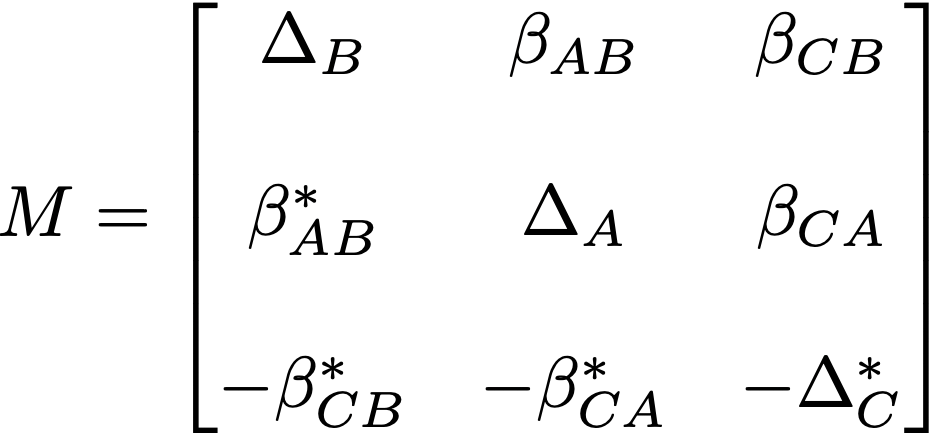

In [9]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I

# Define symbols
Delta_A, Delta_B, Delta_C, beta_BA, beta_CA, beta_CB = symbols('Delta_A Delta_B Delta_C beta_BA beta_CA beta_CB', complex=True)

# Build matrix M
M = Matrix([
    [Delta_A, beta_BA, beta_CA],
    [conjugate(beta_BA), Delta_B, beta_CB],
    [-conjugate(beta_CA), -conjugate(beta_CB), -conjugate(Delta_C)]
])

# Display matrix
print(M)

Matrix([[Delta_A, beta_BA, beta_CA], [conjugate(beta_BA), Delta_B, beta_CB], [-conjugate(beta_CA), -conjugate(beta_CB), -conjugate(Delta_C)]])


$$
M_{\text{Kron}} = 
\begin{bmatrix}
\frac{\Delta_{A0} \left(- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}\right) + \beta_{A0B1} \overline{\Delta_{B0}} \overline{\beta_{A0B1}}}{- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}} & \frac{\beta_{A0A1} \left(- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}\right) + \beta_{A0B1} \overline{\Delta_{B0}} \overline{\beta_{A1B1}} + \beta_{A0B1} \overline{\beta_{A1B0}} \overline{\beta_{B0B1}}}{- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}}\\
\frac{\left(\beta_{A1B0} \beta_{B0B1} + \beta_{A1B1} \overline{\Delta_{B0}}\right) \overline{\beta_{A0B1}} + \left(- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}\right) \overline{\beta_{A0A1}}}{- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}} & \frac{\Delta_{A1} \left(- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}\right) + \left(\beta_{A1B0} \beta_{B0B1} + \beta_{A1B1} \overline{\Delta_{B0}}\right) \overline{\beta_{A1B1}} + \left(\beta_{A1B0} \overline{\Delta_{B1}} + \beta_{A1B1} \overline{\beta_{B0B1}}\right) \overline{\beta_{A1B0}}}{- \overline{\Delta_{B0}} \overline{\Delta_{B1}} + \left|{\beta_{B0B1}}\right|^{2}}
\end{bmatrix}
$$

In [3]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I

# Define symbols
Delta_A, Delta_B, Delta_C, Delta_D, beta_BA, beta_CA, beta_DB, beta_DC = symbols('Delta_A Delta_B Delta_C Delta_D beta_BA beta_CA beta_DB beta_DC', complex=True)

# Build matrix M
M = Matrix([
    [Delta_A, beta_BA, beta_CA, 0],
    [conjugate(beta_BA), Delta_B, 0, beta_DB],
    [conjugate(beta_CA), 0, Delta_C, beta_DC],
    [0, conjugate(beta_DB), conjugate(beta_DC), Delta_D]
])

# Display matrix
print(M)

# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['A', 'B']
# Nodes to eliminate: ['C', 'D']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0, 1]
elim_indices = [2, 3]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
M_kron = M_AA - M_AB * M_BB.inv() * M_BA

# Simplify
M_kron = simplify(M_kron)

# Display
print("Kron-reduced matrix M_kron:")
print(M_kron)
print("\nLaTeX:")
print(latex(M_kron))


Matrix([[Delta_A, beta_BA, beta_CA, 0], [conjugate(beta_BA), Delta_B, 0, beta_DB], [conjugate(beta_CA), 0, Delta_C, beta_DC], [0, conjugate(beta_DB), conjugate(beta_DC), Delta_D]])
Kron-reduced matrix M_kron:
Matrix([[(Delta_A*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) - Delta_D*beta_CA*conjugate(beta_CA))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)), (beta_BA*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) + beta_CA*beta_DC*conjugate(beta_DB))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC))], [(beta_DB*conjugate(beta_CA)*conjugate(beta_DC) + (Delta_C*Delta_D - beta_DC*conjugate(beta_DC))*conjugate(beta_BA))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)), (Delta_B*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) - Delta_C*beta_DB*conjugate(beta_DB))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC))]])

LaTeX:


NameError: name 'latex' is not defined

AttributeError: 'MutableDenseMatrix' object has no attribute 'latex'

In [6]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I, simplify, latex

# Define symbols
Delta_A, Delta_B, Delta_C, Delta_D, beta_BA, beta_CA, beta_DB, beta_DC = symbols('Delta_A Delta_B Delta_C Delta_D beta_BA beta_CA beta_DB beta_DC', complex=True)

# Build matrix M
M = Matrix([
    [Delta_A, beta_BA, beta_CA, 0],
    [conjugate(beta_BA), Delta_B, 0, beta_DB],
    [conjugate(beta_CA), 0, Delta_C, beta_DC],
    [0, conjugate(beta_DB), conjugate(beta_DC), Delta_D]
])

# Display matrix
print(M)

# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['A', 'B']
# Nodes to eliminate: ['C', 'D']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0, 1]
elim_indices = [2, 3]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
M_kron = M_AA - M_AB * M_BB.inv() * M_BA
\frac{1}{\Delta_{C} \Delta_{D} - \left|\beta_{DC}\right|^{2}} \left[\begin{matrix}\Delta_{A} \left(\Delta_{C} \Delta_{D} - \left|\beta_{DC}\right|^{2}\right) - \Delta_{D} \left|\beta_{CA}\right|^{2} & \beta_{BA} \left(\Delta_{C} \Delta_{D} - \left|\beta_{DC}\right|^{2}\right) + \beta_{CA} \beta_{DC} \beta_{DB}^{*}\\\beta_{DB} \beta_{CA}^{*} \beta_{DC}^{*} + \left(\Delta_{C} \Delta_{D} - \left|\beta_{DC}\right|^{2}\right) \beta_{BA}^{*} & \Delta_{B} \left(\Delta_{C} \Delta_{D} - \left|\beta_{DC}\right|^{2}\right) - \Delta_{C} \left|\beta_{DB}\right|^{2}\end{matrix}\right]
# Simplify
M_kron = simplify(M_kron)

# Display
print("Kron-reduced matrix M_kron:")
print(M_kron)
print("\nLaTeX:")
print(latex(M_kron))


Matrix([[Delta_A, beta_BA, beta_CA, 0], [conjugate(beta_BA), Delta_B, 0, beta_DB], [conjugate(beta_CA), 0, Delta_C, beta_DC], [0, conjugate(beta_DB), conjugate(beta_DC), Delta_D]])
Kron-reduced matrix M_kron:
Matrix([[(Delta_A*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) - Delta_D*beta_CA*conjugate(beta_CA))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)), (beta_BA*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) + beta_CA*beta_DC*conjugate(beta_DB))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC))], [(beta_DB*conjugate(beta_CA)*conjugate(beta_DC) + (Delta_C*Delta_D - beta_DC*conjugate(beta_DC))*conjugate(beta_BA))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)), (Delta_B*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) - Delta_C*beta_DB*conjugate(beta_DB))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC))]])

LaTeX:
\left[\begin{matrix}\frac{\Delta_{A} \left(\Delta_{C} \Delta_{D} - \beta_{DC} \overline{\beta_{DC}}\right) - \Delta_{D} \beta_{CA} \overline{\beta_{CA}}}{\Delta_{C} \Delta_{D} - \b

In [8]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I, simplify, latex

# Define symbols
Delta_A, Delta_B, Delta_C, Delta_D, beta_BA, beta_CA, beta_DB, beta_DC = symbols('Delta_A Delta_B Delta_C Delta_D beta_BA beta_CA beta_DB beta_DC', complex=True)

# Build matrix M
M = Matrix([
    [Delta_A, beta_BA, beta_CA, 0],
    [conjugate(beta_BA), Delta_B, 0, beta_DB],
    [-conjugate(beta_CA), 0, -conjugate(Delta_C), -beta_DC],
    [0, -conjugate(beta_DB), -conjugate(beta_DC), -conjugate(Delta_D)]
])

# Display matrix
print(M)

# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['A', 'B']
# Nodes to eliminate: ['C_conj', 'D_conj']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0, 1]
elim_indices = [2, 3]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
M_kron = M_AA - M_AB * M_BB.inv() * M_BA

# Simplify
M_kron = simplify(M_kron)

# Display
print("Kron-reduced matrix M_kron:")
print(M_kron)
print("\nLaTeX:")
print(latex(M_kron))


Matrix([[Delta_A, beta_BA, beta_CA, 0], [conjugate(beta_BA), Delta_B, 0, beta_DB], [-conjugate(beta_CA), 0, -conjugate(Delta_C), -beta_DC], [0, -conjugate(beta_DB), -conjugate(beta_DC), -conjugate(Delta_D)]])
Kron-reduced matrix M_kron:
Matrix([[(Delta_A*(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)) + beta_CA*conjugate(Delta_D)*conjugate(beta_CA))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)), (beta_BA*(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)) - beta_CA*beta_DC*conjugate(beta_DB))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D))], [(-beta_DB*conjugate(beta_CA)*conjugate(beta_DC) + (beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D))*conjugate(beta_BA))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)), (Delta_B*(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)) + beta_DB*conjugate(Delta_C)*conjugate(beta_DB))/(beta_DC*conjugate(beta_DC) - con

In [9]:
M_kron

Matrix([
[            (Delta_A*(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)) + beta_CA*conjugate(Delta_D)*conjugate(beta_CA))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)),            (beta_BA*(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)) - beta_CA*beta_DC*conjugate(beta_DB))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D))],
[(-beta_DB*conjugate(beta_CA)*conjugate(beta_DC) + (beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D))*conjugate(beta_BA))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)), (Delta_B*(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D)) + beta_DB*conjugate(Delta_C)*conjugate(beta_DB))/(beta_DC*conjugate(beta_DC) - conjugate(Delta_C)*conjugate(Delta_D))]])

In [10]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I, simplify, latex

# Define symbols
Delta_A, Delta_B, Delta_C, Delta_D, beta_BA, beta_CA, beta_DB, beta_DC = symbols('Delta_A Delta_B Delta_C Delta_D beta_BA beta_CA beta_DB beta_DC', complex=True)

# Build matrix M
M = Matrix([
    [Delta_A, beta_BA, beta_CA, 0],
    [conjugate(beta_BA), Delta_B, 0, beta_DB],
    [conjugate(beta_CA), 0, Delta_C, beta_DC],
    [0, conjugate(beta_DB), conjugate(beta_DC), Delta_D]
])

# Display matrix
print(M)

# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['A', 'B']
# Nodes to eliminate: ['C', 'D']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0, 1]
elim_indices = [2, 3]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
M_kron = M_AA - M_AB * M_BB.inv() * M_BA

# Simplify
M_kron = simplify(M_kron)

# Display
print("Kron-reduced matrix M_kron:")
print(M_kron)
print("\nLaTeX:")
print(latex(M_kron))


# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['A']
# Nodes to eliminate: ['B', 'C', 'D']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0]
elim_indices = [1, 2, 3]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
M_kron = M_AA - M_AB * M_BB.inv() * M_BA

# Simplify
M_kron = simplify(M_kron)

# Display
print("Kron-reduced matrix M_kron:")
print(M_kron)
print("\nLaTeX:")
print(latex(M_kron))


Matrix([[Delta_A, beta_BA, beta_CA, 0], [conjugate(beta_BA), Delta_B, 0, beta_DB], [conjugate(beta_CA), 0, Delta_C, beta_DC], [0, conjugate(beta_DB), conjugate(beta_DC), Delta_D]])
Kron-reduced matrix M_kron:
Matrix([[(Delta_A*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) - Delta_D*beta_CA*conjugate(beta_CA))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)), (beta_BA*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) + beta_CA*beta_DC*conjugate(beta_DB))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC))], [(beta_DB*conjugate(beta_CA)*conjugate(beta_DC) + (Delta_C*Delta_D - beta_DC*conjugate(beta_DC))*conjugate(beta_BA))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)), (Delta_B*(Delta_C*Delta_D - beta_DC*conjugate(beta_DC)) - Delta_C*beta_DB*conjugate(beta_DB))/(Delta_C*Delta_D - beta_DC*conjugate(beta_DC))]])

LaTeX:
\left[\begin{matrix}\frac{\Delta_{A} \left(\Delta_{C} \Delta_{D} - \beta_{DC} \overline{\beta_{DC}}\right) - \Delta_{D} \beta_{CA} \overline{\beta_{CA}}}{\Delta_{C} \Delta_{D} - \b

In [3]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I, simplify, latex

# Define symbols
Delta_A, Delta_B, Delta_C, beta_BA, beta_CA, beta_CB = symbols('Delta_A Delta_B Delta_C beta_BA beta_CA beta_CB', complex=True)

# Build matrix M
M = Matrix([
    [Delta_A, beta_BA, beta_CA],
    [conjugate(beta_BA), Delta_B, beta_CB],
    [-conjugate(beta_CA), -conjugate(beta_CB), -conjugate(Delta_C)]
])

# Display matrix
print(M)

# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['A', 'B']
# Nodes to eliminate: ['C_conj']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0, 1]
elim_indices = [2]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
M_kron = M_AA - M_AB * M_BB.inv() * M_BA

# Simplify
M_kron = simplify(M_kron)

# Display
print("Kron-reduced matrix M_kron:")
print(M_kron)
print("\nLaTeX:")
print(latex(M_kron))


Matrix([[Delta_A, beta_BA, beta_CA], [conjugate(beta_BA), Delta_B, beta_CB], [-conjugate(beta_CA), -conjugate(beta_CB), -conjugate(Delta_C)]])
Kron-reduced matrix M_kron:
Matrix([[Delta_A - beta_CA*conjugate(beta_CA)/conjugate(Delta_C), beta_BA - beta_CA*conjugate(beta_CB)/conjugate(Delta_C)], [-beta_CB*conjugate(beta_CA)/conjugate(Delta_C) + conjugate(beta_BA), Delta_B - beta_CB*conjugate(beta_CB)/conjugate(Delta_C)]])

LaTeX:
\left[\begin{matrix}\Delta_{A} - \frac{\beta_{CA} \overline{\beta_{CA}}}{\overline{\Delta_{C}}} & \beta_{BA} - \frac{\beta_{CA} \overline{\beta_{CB}}}{\overline{\Delta_{C}}}\\- \frac{\beta_{CB} \overline{\beta_{CA}}}{\overline{\Delta_{C}}} + \overline{\beta_{BA}} & \Delta_{B} - \frac{\beta_{CB} \overline{\beta_{CB}}}{\overline{\Delta_{C}}}\end{matrix}\right]


In [5]:
print(latex(M_kron))

\left[\begin{matrix}\Delta_{A} - \frac{\beta_{CA} \overline{\beta_{CA}}}{\overline{\Delta_{C}}} & \beta_{BA} - \frac{\beta_{CA} \overline{\beta_{CB}}}{\overline{\Delta_{C}}}\\- \frac{\beta_{CB} \overline{\beta_{CA}}}{\overline{\Delta_{C}}} + \overline{\beta_{BA}} & \Delta_{B} - \frac{\beta_{CB} \overline{\beta_{CB}}}{\overline{\Delta_{C}}}\end{matrix}\right]


In [25]:
# Import SymPy
from sympy import symbols, Matrix, conjugate, I, simplify, latex

# Define symbols
Delta_0, Delta_1, Delta_2, Delta_3, Delta_4, Delta_5, beta_10, beta_21, beta_32, beta_43, beta_54 = symbols('Delta_0 Delta_1 Delta_2 Delta_3 Delta_4 Delta_5 beta_10 beta_21 beta_32 beta_43 beta_54', complex=True)

# Build matrix M
M = Matrix([
    [Delta_0, beta_10, 0, 0, 0, 0],
    [conjugate(beta_10), Delta_1, beta_21, 0, 0, 0],
    [0, conjugate(beta_21), Delta_2, beta_32, 0, 0],
    [0, 0, conjugate(beta_32), Delta_3, beta_43, 0],
    [0, 0, 0, conjugate(beta_43), Delta_4, beta_54],
    [0, 0, 0, 0, conjugate(beta_54), Delta_5]
])

# Display matrix
print(M)

# ======================================================================
# Kron Reduction
# ======================================================================

# Using the matrix M defined above
# Nodes to keep: ['0']
# Nodes to eliminate: ['1', '2', '3', '4', '5']

# Partition M into blocks:
# M = [M_AA  M_AB]
#     [M_BA  M_BB]
# where A = kept nodes, B = eliminated nodes

kept_indices = [0]
elim_indices = [1, 2, 3, 4, 5]

# Extract blocks
M_AA = Matrix([[M[i, j] for j in kept_indices] for i in kept_indices])
M_AB = Matrix([[M[i, j] for j in elim_indices] for i in kept_indices])
M_BA = Matrix([[M[i, j] for j in kept_indices] for i in elim_indices])
M_BB = Matrix([[M[i, j] for j in elim_indices] for i in elim_indices])

# Compute Schur complement (Kron-reduced matrix)
# M_kron = M_AA - M_AB * M_BB.inv() * M_BA
M_kron = M_AA - M_AB * M_BB.inv(method='LU') * M_BA
# M_kron = M_AA - M_AB * M_BB.inv(method='ADJ') * M_BA

# Simplify
M_kron = simplify(M_kron)

# # Display
# print("Kron-reduced matrix M_kron:")
# print(M_kron)
# print("\nLaTeX:")
# print(latex(M_kron))

# M_kron

# ======================================================================
# Continued Fraction Expansion
# ======================================================================

from sympy import div, Poly, fraction, cancel

# Extract the single element (since M_kron is 1x1)
m_kron_element = M_kron[0, 0]

# Simplify and get numerator and denominator
m_kron_element = cancel(m_kron_element)
numer, denom = fraction(m_kron_element)

print("\nM_kron element:")
print(m_kron_element)
print("\nNumerator:", numer)
print("Denominator:", denom)

# Compute continued fraction expansion
# For a chain graph, this will give you the iterative structure
def polynomial_continued_fraction(num, den, max_terms=20):
    """Compute continued fraction expansion of num/den"""
    cf_terms = []
    
    for i in range(max_terms):
        if den == 0:
            break
            
        # Polynomial division: num = q * den + r
        q, r = div(num, den, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')
        
        cf_terms.append(q)
        
        if r == 0:
            break
        
        # Continue with reciprocal: den/r
        num, den = den, r
    
    return cf_terms

# Get continued fraction
cf = polynomial_continued_fraction(numer, denom)

print("\nContinued fraction terms:")
for i, term in enumerate(cf):
    print(f"a_{i} = {term}")

# Reconstruct to verify
def reconstruct_cf(terms):
    """Reconstruct rational function from continued fraction terms"""
    if len(terms) == 0:
        return 0
    if len(terms) == 1:
        return terms[0]
    
    result = terms[-1]
    for term in reversed(terms[:-1]):
        result = term + 1/result
    return simplify(result)

if len(cf) > 0:
    reconstructed = reconstruct_cf(cf)
    print("\nReconstructed from CF:")
    print(simplify(reconstructed))
    print("\nDifference from original:")
    print(simplify(reconstructed - m_kron_element))

Matrix([[Delta_0, beta_10, 0, 0, 0, 0], [conjugate(beta_10), Delta_1, beta_21, 0, 0, 0], [0, conjugate(beta_21), Delta_2, beta_32, 0, 0], [0, 0, conjugate(beta_32), Delta_3, beta_43, 0], [0, 0, 0, conjugate(beta_43), Delta_4, beta_54], [0, 0, 0, 0, conjugate(beta_54), Delta_5]])

M_kron element:
(Delta_0*Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_0*Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_0*Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_0*Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_0*Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_0*Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_0*Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_0*Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43) - Delta_2*Delta_3*Delta_4*Delta_5*beta_10*conjugate(beta_10) + Delta_2*Delta_3*beta_10*beta_54*conjugate(beta_10)*conjugate(beta_54) + Delta_2*Delta_5*beta_10*beta_43*conjugate(beta_10)*conjugat

In [49]:
# Extract the single element (since M_kron is 1x1)
m_kron_element = M_kron[0, 0]
m_kron_element
# # Simplify and get numerator and denominator
# m_kron_element = cancel(m_kron_element)
# numer, denom = fraction(m_kron_element)

(Delta_0*Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_0*Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_0*Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_0*Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_0*Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_0*Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_0*Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_0*Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43) - Delta_2*Delta_3*Delta_4*Delta_5*beta_10*conjugate(beta_10) + Delta_2*Delta_3*beta_10*beta_54*conjugate(beta_10)*conjugate(beta_54) + Delta_2*Delta_5*beta_10*beta_43*conjugate(beta_10)*conjugate(beta_43) + Delta_4*Delta_5*beta_10*beta_32*conjugate(beta_10)*conjugate(beta_32) - beta_10*beta_32*beta_54*conjugate(beta_10)*conjugate(beta_32)*conjugate(beta_54))/(Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*co

In [50]:
cancel(m_kron_element)

(Delta_0*Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_0*Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_0*Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_0*Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_0*Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_0*Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_0*Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_0*Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43) - Delta_2*Delta_3*Delta_4*Delta_5*beta_10*conjugate(beta_10) + Delta_2*Delta_3*beta_10*beta_54*conjugate(beta_10)*conjugate(beta_54) + Delta_2*Delta_5*beta_10*beta_43*conjugate(beta_10)*conjugate(beta_43) + Delta_4*Delta_5*beta_10*beta_32*conjugate(beta_10)*conjugate(beta_32) - beta_10*beta_32*beta_54*conjugate(beta_10)*conjugate(beta_32)*conjugate(beta_54))/(Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*co

In [58]:
numer, denom = fraction(m_kron_element)

In [59]:
numer

Delta_0*Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_0*Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_0*Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_0*Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_0*Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_0*Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_0*Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_0*Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43) - Delta_2*Delta_3*Delta_4*Delta_5*beta_10*conjugate(beta_10) + Delta_2*Delta_3*beta_10*beta_54*conjugate(beta_10)*conjugate(beta_54) + Delta_2*Delta_5*beta_10*beta_43*conjugate(beta_10)*conjugate(beta_43) + Delta_4*Delta_5*beta_10*beta_32*conjugate(beta_10)*conjugate(beta_32) - beta_10*beta_32*beta_54*conjugate(beta_10)*conjugate(beta_32)*conjugate(beta_54)

In [60]:
denom

Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43)

In [81]:
q, r = div(numer, denom, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')
display(q)
display(r)
# numer, denom = denom, r
numer = denom
denom = r

0

-Delta_2*Delta_3*Delta_4*Delta_5*beta_10*conjugate(beta_10) + Delta_2*Delta_3*beta_10*beta_54*conjugate(beta_10)*conjugate(beta_54) + Delta_2*Delta_5*beta_10*beta_43*conjugate(beta_10)*conjugate(beta_43) + Delta_4*Delta_5*beta_10*beta_32*conjugate(beta_10)*conjugate(beta_32) - beta_10*beta_32*beta_54*conjugate(beta_10)*conjugate(beta_32)*conjugate(beta_54)

In [ ]:
q, r = div(numer, denom, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')
display(q)
display(r)
# numer, denom = denom, r

0

Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43)

In [46]:
q, r = div(numer, denom, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')
display(q)
display(r)
numer, denom = denom, r

0

Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43)

In [47]:
q, r = div(numer, denom, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')
display(q)
display(r)
numer, denom = denom, r

0

-Delta_2*Delta_3*Delta_4*Delta_5*beta_10*conjugate(beta_10) + Delta_2*Delta_3*beta_10*beta_54*conjugate(beta_10)*conjugate(beta_54) + Delta_2*Delta_5*beta_10*beta_43*conjugate(beta_10)*conjugate(beta_43) + Delta_4*Delta_5*beta_10*beta_32*conjugate(beta_10)*conjugate(beta_32) - beta_10*beta_32*beta_54*conjugate(beta_10)*conjugate(beta_32)*conjugate(beta_54)

In [48]:
q, r = div(numer, denom, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')
display(q)
display(r)
numer, denom = denom, r

0

Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43)

In [37]:
q, r = div(denom, r, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')

In [38]:
q

0

In [39]:
r

Delta_1*Delta_2*Delta_3*Delta_4*Delta_5 - Delta_1*Delta_2*Delta_3*beta_54*conjugate(beta_54) - Delta_1*Delta_2*Delta_5*beta_43*conjugate(beta_43) - Delta_1*Delta_4*Delta_5*beta_32*conjugate(beta_32) + Delta_1*beta_32*beta_54*conjugate(beta_32)*conjugate(beta_54) - Delta_3*Delta_4*Delta_5*beta_21*conjugate(beta_21) + Delta_3*beta_21*beta_54*conjugate(beta_21)*conjugate(beta_54) + Delta_5*beta_21*beta_43*conjugate(beta_21)*conjugate(beta_43)

In [ ]:
q, r = div(denom, r, domain='ZZ[Delta_0,Delta_1,Delta_2,Delta_3,Delta_4,Delta_5,beta_10,beta_21,beta_32,beta_43,beta_54]')  

In [22]:
# Alternative: Direct continued fraction for chain elimination
def chain_continued_fraction_form():
    """Express the Kron reduction as an explicit continued fraction"""
    print("\nContinued fraction form (chain graph):")
    print("M_kron = Delta_0 - |beta_10|²/(Delta_1 - |beta_21|²/(Delta_2 - |beta_32|²/(Delta_3 - |beta_43|²/(Delta_4 - |beta_54|²/Delta_5))))")
    
    # Build it iteratively from the end
    cf = Delta_5
    cf = Delta_4 - conjugate(beta_54) * beta_54 / cf
    cf = Delta_3 - conjugate(beta_43) * beta_43 / cf
    cf = Delta_2 - conjugate(beta_32) * beta_32 / cf
    cf = Delta_1 - conjugate(beta_21) * beta_21 / cf
    cf = Delta_0 - conjugate(beta_10) * beta_10 / cf
    
    return simplify(cf)

cf_direct = chain_continued_fraction_form()
print("\nDirect CF computation:")
print(cf_direct)
print("\nDifference from M_kron:")
print(simplify(cf_direct - m_kron_element))


Continued fraction form (chain graph):
M_kron = Delta_0 - |beta_10|²/(Delta_1 - |beta_21|²/(Delta_2 - |beta_32|²/(Delta_3 - |beta_43|²/(Delta_4 - |beta_54|²/Delta_5))))

Direct CF computation:
Delta_0 - beta_10*conjugate(beta_10)/(Delta_1 - beta_21*conjugate(beta_21)/(Delta_2 - beta_32*conjugate(beta_32)/(Delta_3 - beta_43*conjugate(beta_43)/(Delta_4 - beta_54*conjugate(beta_54)/Delta_5))))

Difference from M_kron:
0


In [24]:
cf

[Delta_0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [14]:
# M.inv()
# M.inv(method='LU')
M.inv(method='ADJ')

Matrix([
[(Delta_1*(-Delta_2*(-Delta_3*(Delta_4*Delta_5 - beta_54*conjugate(beta_54)) - Delta_4*beta_43*conjugate(beta_43) - beta_43*(-Delta_4 - Delta_5)*conjugate(beta_43)) - Delta_3*beta_32*(-Delta_3 - Delta_4 - Delta_5)*conjugate(beta_32) - beta_32*(Delta_3**2*conjugate(beta_32) + beta_43*conjugate(beta_32)*conjugate(beta_43)) - beta_32*(-Delta_3*(-Delta_4 - Delta_5) + Delta_4*Delta_5 - beta_43*conjugate(beta_43) - beta_54*conjugate(beta_54))*conjugate(beta_32)) + Delta_2*beta_21*(-Delta_2*(-Delta_3 - Delta_4 - Delta_5) - Delta_3*(-Delta_4 - Delta_5) + Delta_4*Delta_5 - beta_32*conjugate(beta_32) - beta_43*conjugate(beta_43) - beta_54*conjugate(beta_54))*conjugate(beta_21) + beta_21*(Delta_2*(Delta_2**2*conjugate(beta_21) + beta_32*conjugate(beta_21)*conjugate(beta_32)) + beta_32*(Delta_2*conjugate(beta_21)*conjugate(beta_32) + Delta_3*conjugate(beta_21)*conjugate(beta_32))) + beta_21*(Delta_2**2*conjugate(beta_21) + beta_32*conjugate(beta_21)*conjugate(beta_32))*(-Delta_2 - Delta_3